# Лабораторная работа 1


In [115]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette("Set2")  
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)



## Датасет
Pantheon - датасет с информацией об известных исторических и современных личностях. Ссылка: https://pantheon.world/data/datasets

In [116]:
DATA_PATH = "person_2025_update.csv.bz2" 

df = pd.read_csv(DATA_PATH, low_memory=False, compression='bz2')
for col in ['birthyear','deathyear','hpi','hpi_raw','age','non_en_page_views','prob_ratio','coefficient_of_variation','l','l_']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
for date_col in ['birthdate','deathdate']:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

if 'birthyear' in df.columns:
    df['birth_decade'] = (df['birthyear']//10)*10
if 'birthyear' in df.columns and 'deathyear' in df.columns:
    df['computed_age'] = df['deathyear'] - df['birthyear']
if 'gender' in df.columns:
    df['gender'] = df['gender'].fillna('unknown').astype(str)
if 'occupation' in df.columns:
    df['occupation'] = df['occupation'].fillna('UNKNOWN').astype(str)


##### Некоторые колонки:
##### 1. birthyear - год рождения известной личности
##### 2. occupation - род занятий личности
##### 3. gender - пол личности
##### 4. bplace_country - страна рождения
##### 5. non_en_page_views - количество просмотров страницы данной личности на википедии на всех доступных языках, кроме английского
##### 6. HPI - индекс исторической известности
##### 7. birtdate - дата рождения
##### 8. bplace_lon, bplace_lat - долгота и широта места рождения

# Диаграммы

### 1. Гистограммы — распределение годов рождения (birthyear)

Зачем: показывает, в какие исторические периоды приходится наибольшее число персон в датасете. Оси: x — год рождения, y — количество. Полезно для понимания временного покрытия датасета.

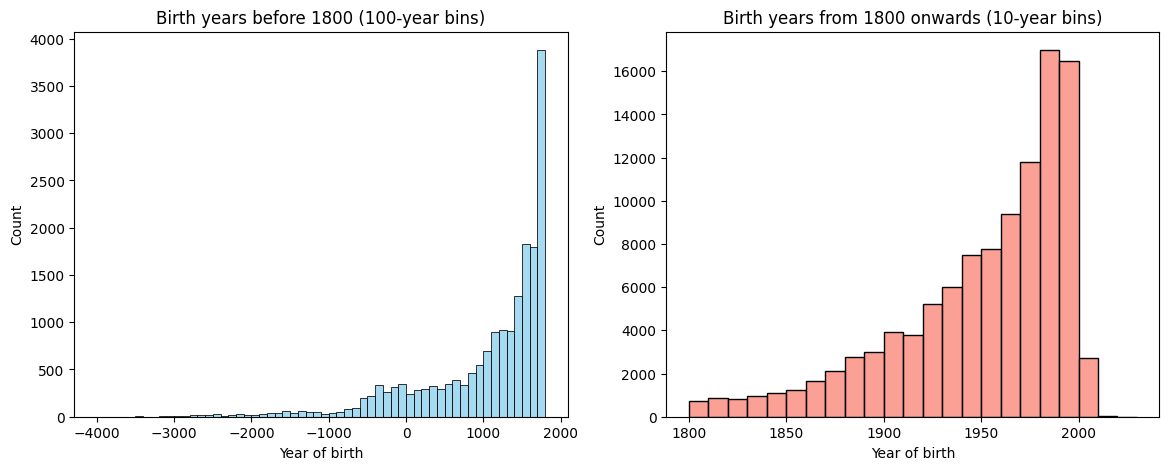

In [117]:
plt.figure(figsize=(14,5))
by = df['birthyear'].dropna()

plt.subplot(1,2,1)
pre1800 = by[by < 1800]
bins_pre = range(int(pre1800.min())//100*100, 1801, 100)
sns.histplot(pre1800, bins=bins_pre, color='skyblue', edgecolor='black')
plt.xlabel('Year of birth')
plt.ylabel('Count')
plt.title('Birth years before 1800 (100-year bins)')

plt.subplot(1,2,2)
post1800 = by[by >= 1800]
bins_post = range(1800, int(post1800.max())+10, 10)
sns.histplot(post1800, bins=bins_post, color='salmon', edgecolor='black')
plt.xlabel('Year of birth')
plt.ylabel('Count')
plt.title('Birth years from 1800 onwards (10-year bins)')

plt.show()


### 2. Столбчатая диаграмма — топ-10 профессий (occupation)

Зачем: показывает наиболее частые занятия/роли. Оси: x — профессия (обрезанная до топ-10), y — количество записей.

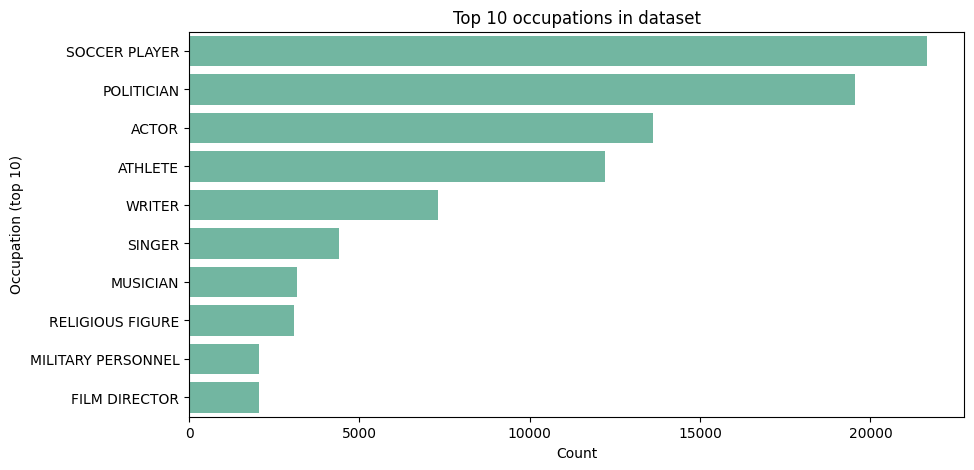

In [118]:
plt.figure(figsize=(10,5))
top = df['occupation'].value_counts().nlargest(10)
sns.barplot(x=top.values, y=top.index)
plt.xlabel('Count')
plt.ylabel('Occupation (top 10)')
plt.title('Top 10 occupations in dataset')
plt.show()


### 3. Круговая диаграмма — распределение по полу (gender)

Зачем: показывает доли категорий пола в датасете.

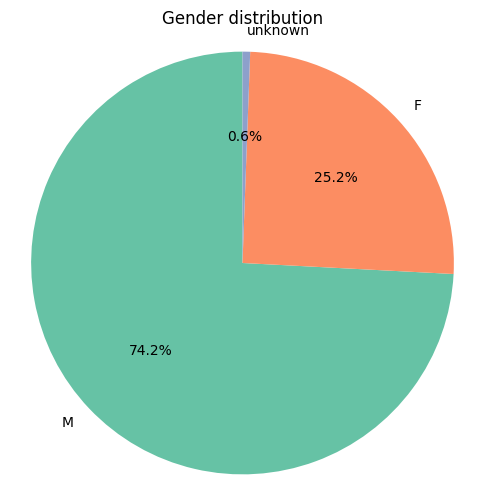

In [119]:
plt.figure(figsize=(6,6))
g = df['gender'].fillna('unknown').value_counts()
plt.pie(g.values, labels=g.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender distribution')
plt.axis('equal')
plt.show()

### 4. Линейный график — количество персон по странам рождения (топ-20)

Зачем: показать, в каких странах родилось больше всего известных персон в датасете.
Ось x — страны рождения (топ-20 по числу персон), ось y — количество персон.

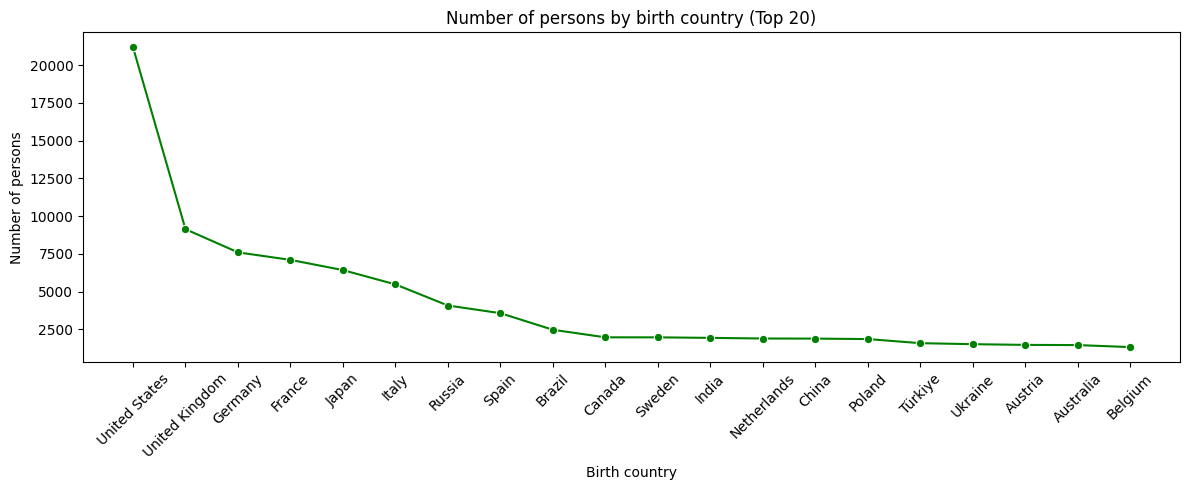

In [120]:
plt.figure(figsize=(12,5))

country_counts = df['bplace_country'].value_counts().head(20)  # топ-20 стран
    
sns.lineplot(x=country_counts.index, y=country_counts.values, marker='o', color='green')
plt.xticks(rotation=45)
plt.xlabel('Birth country')
plt.ylabel('Number of persons')
plt.title('Number of persons by birth country (Top 20)')
plt.tight_layout()


### 5. Stripplot — распределение просмотров страниц на других языках по гендеру

Зачем: показать, как различается число просмотров страниц на других языках (non_en_page_views) между половыми категориями.
Ось x — гендер, ось y — количество просмотров на других языках.


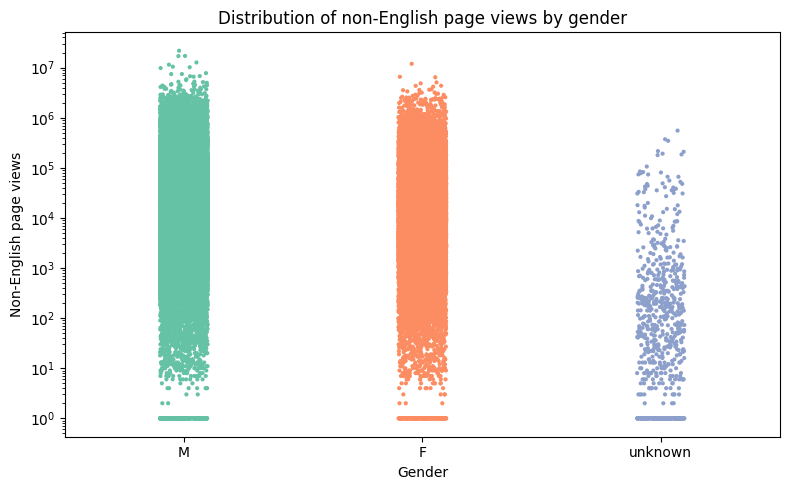

In [121]:
plt.figure(figsize=(8,5))

sub = df[df['non_en_page_views'].notna() & df['gender'].notna()]
    
sns.stripplot(x='gender', y='non_en_page_views', data=sub, size=3, jitter=True, palette='Set2')
plt.yscale('log')
plt.xlabel('Gender')
plt.ylabel('Non-English page views')
plt.title('Distribution of non-English page views by gender')
plt.tight_layout()


### 6. Диаграмма рассеяния — HPI vs non_en_page_views

Зачем: исследовать связь между HPI и числом просмотров не англоязычных страниц (non_en_page_views). Используем лог шкалу для просмотров. Оси: x — non_en_page_views (log), y — hpi.

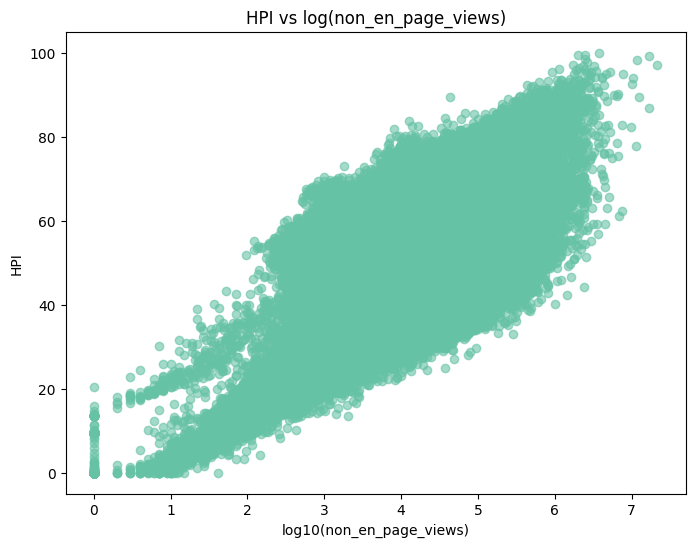

In [122]:
plt.figure(figsize=(8,6))
sub = df[df['hpi'].notna() & df['non_en_page_views'].notna()].copy()
sub['views_pos'] = sub['non_en_page_views'].clip(lower=1)
plt.scatter(np.log10(sub['views_pos']), sub['hpi'], alpha=0.6)
plt.xlabel('log10(non_en_page_views)')
plt.ylabel('HPI')
plt.title('HPI vs log(non_en_page_views)')
plt.show()


### 7. Столбчатая диаграмма — количество персон по месяцам рождения

Зачем: показать распределение количества известных персон по месяцам рождения.
Ось x — месяц рождения, ось y — число персон, родившихся в каждом месяце.

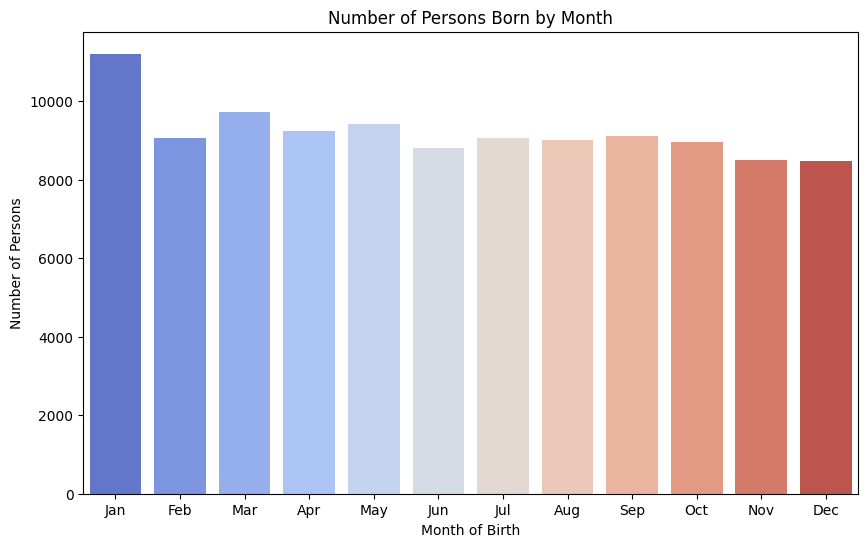

In [123]:
plt.figure(figsize=(10,6))

bd = df['birthdate'].dropna()
bd = pd.to_datetime(bd, errors='coerce').dropna()
months = bd.dt.month
month_counts = months.value_counts().sort_index()
    
sns.barplot(x=month_counts.index, y=month_counts.values, palette='coolwarm')
plt.xlabel('Month of Birth')
plt.ylabel('Number of Persons')
plt.title('Number of Persons Born by Month')
plt.xticks(ticks=range(0,12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

### 8. KDE — оценка плотности распределения HPI

Зачем: дать непрерывную оценку распределения HPI; помогает увидеть моды и сглаженную форму распределения. Оси: x — HPI, y — оценка плотности.

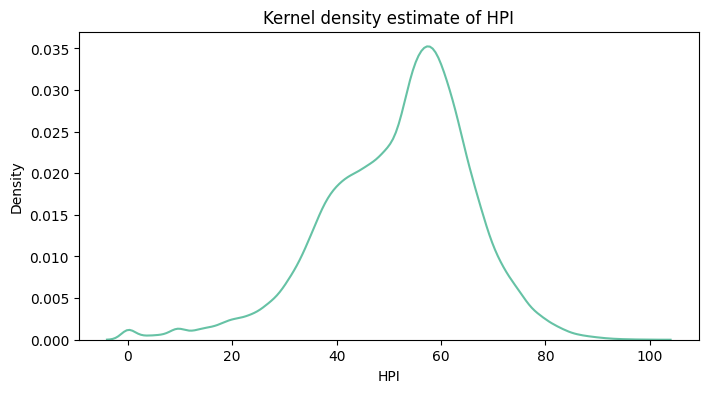

In [ ]:
plt.figure(figsize=(8,4))
sns.kdeplot(df['hpi'].dropna(), bw_adjust=1)
plt.xlabel('HPI')
plt.title('Kernel density estimate of HPI')
plt.show()

### 9. Тепловая карта — корреляционная матрица числовых признаков

Зачем: увидеть корреляции между числовыми признаками (hpi, birthyear, deathyear, age, non_en_page_views и т.д.). Это помогает выявлять зависимости между столбцами.

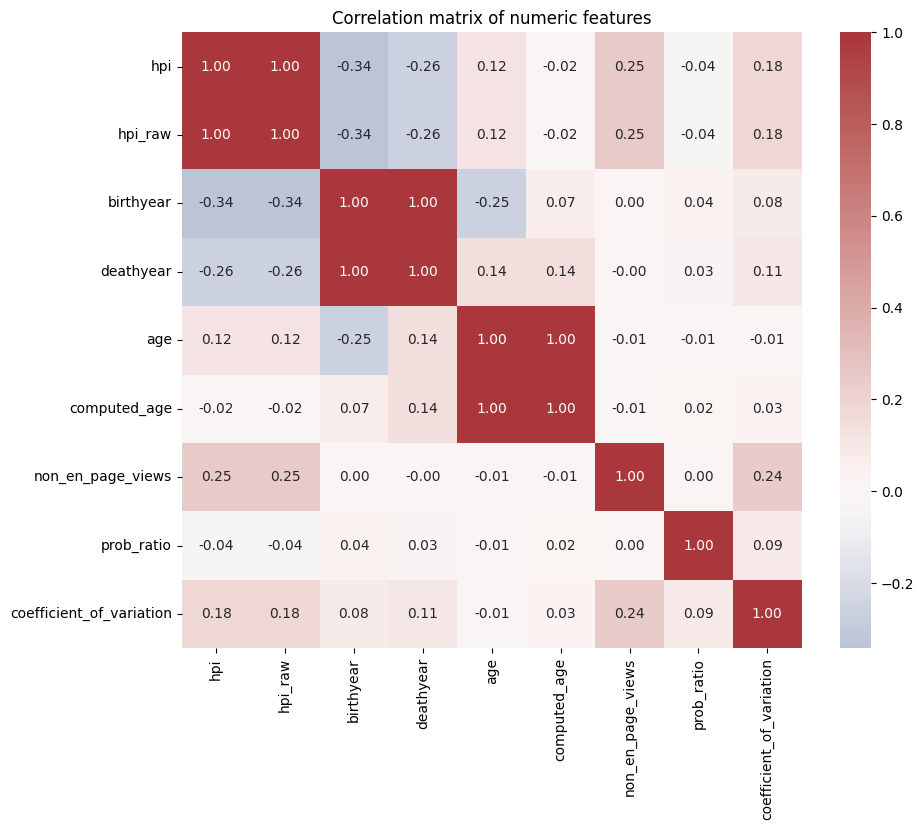

In [128]:
plt.figure(figsize=(10,8))
num_cols = ['hpi','hpi_raw','birthyear','deathyear','age','computed_age','non_en_page_views','prob_ratio','coefficient_of_variation']
exist = [c for c in num_cols if c in df.columns]
corr = df[exist].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation matrix of numeric features')
plt.show()


### 10. Географическая диаграмма (scatter) — координаты места рождения (bplace_lat, bplace_lon)

Зачем: увидеть пространственное распределение персон по местам рождения и цветом обозначить HPI (или плотность). Оси: longitude (x), latitude (y).

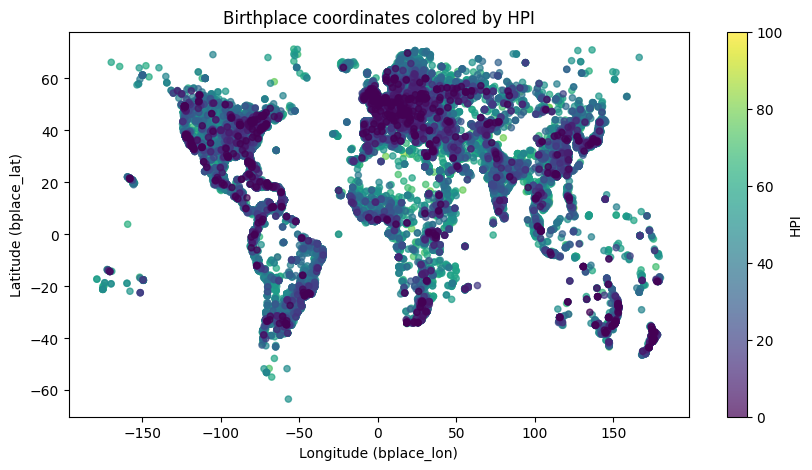

In [127]:
plt.figure(figsize=(10,5))
sub = df[df['bplace_lon'].notna() & df['bplace_lat'].notna()]
sc = plt.scatter(sub['bplace_lon'], sub['bplace_lat'], c=sub['hpi'], s=20, cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='HPI')
plt.xlabel('Longitude (bplace_lon)')
plt.ylabel('Latitude (bplace_lat)')
plt.title('Birthplace coordinates colored by HPI')
plt.show()